### Optimal control of the noisy Wilson-Cowan odel
This notebook shows how to compute the optimal control (OC) signal for the noisy WC model for a simple example task.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

while os.getcwd().split(os.sep)[-1] != "neurolib":
    os.chdir('..')

# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.models.aln import ALNModel

from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, oc_aln, cost_functions
from neurolib.utils.plot_oc import plot_oc_singlenode

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

datadir = os.path.join("examples", "data")

We stimulate the system with a known control signal, define the resulting activity as target, and compute the optimal control for this target. We define weights such that precision is penalized only (w_p=1, w_2=0). Hence, the optimal control signal should converge to the input signal.

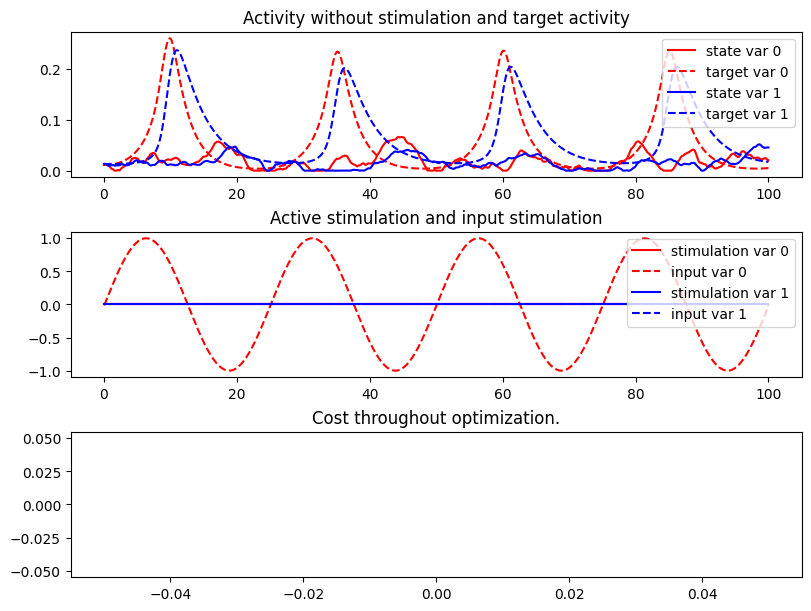

In [3]:
# We import the model
model = WCModel()

# Set noise strength to zero to define target state
model.params.sigma_ou = 0.

# Some parameters to define stimulation signals
dt = model.params["dt"]
duration = 100.
amplitude = 1.
period = duration / 4.

# We define a "zero-input", and a sine-input
zero_input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input = np.copy(zero_input)
input[0,1:-1] = amplitude * np.sin(2.*np.pi*np.arange(0,duration-0.1, dt)/period) # other functions or random values can be used as well

# We set the duration of the simulation and the initial values
model.params["duration"] = duration
x_init = 0.011225367461896877
y_init = 0.013126741089502588
model.params["exc_init"] = np.array([[x_init]])
model.params["inh_init"] = np.array([[y_init]])

# We set the stimulus in x and y variables, and run the simulation
model.params["exc_ext"] = input
model.params["inh_ext"] = zero_input
model.run()

# Define the result of the stimulation as target
target = np.concatenate((np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis],
    np.stack( (model.exc, model.inh), axis=1)), axis=2)
target_input = np.concatenate( (input,zero_input), axis=0)[np.newaxis,:,:]

# Remove stimuli and re-run the simulation
# Change sigma_ou_parameter to adjust the noise strength
sigma = 0.05
model.params['sigma_ou'] = sigma
model.params['tau_ou'] = 1.
model.params["exc_ext"] = zero_input
model.params["inh_ext"] = zero_input
control = np.concatenate( (zero_input,zero_input), axis=0)[np.newaxis,:,:]
model.run()

# combine initial value and simulation result to one array
state = np.concatenate((np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis],
    np.stack( (model.exc, model.inh), axis=1)), axis=2)

plot_oc_singlenode(duration, dt, state, target, control, target_input)

The target is a periodic oscillation of x and y variable (computed in deterministic, noise-free system).

The noisy, undistrubed system fluctuates around zero.

For the optimization, you can now set several new parameters:
- M: the number of noise realizations that the algorithm averages over. Default=1
- M_validation: the number of noise realization the final cost is computed from. Default=1000
- validate_per_step: If True, the cost for each step is computed averaging over M_validation instead of M realizations, this takes much longer. Default=False
- method: determines, how the noise averages are computed. Results may vary for different methods depending on the specific task. Choose from ['3']. Default='3'

Please note:
- higher number of iterations does not promise better results for computations in noisy systems. The cost will level off at some iteration number, and start increasing again afterwards. Make sure not to perform too many iterations.
- M, M_validation should increase with sigma_ou model parameter
- validate_per_step does not impact the control result

Let's first optimize! M is found via the implemented function find_M, the algorithm is aborted if no improvement is achieved in three subsequent iterations. The algorithm returns the control value coresponding to the smallest cost throughout all iterations.

Optimal control with target time series
Recommended M for computation of noisy OC:  23
Compute control for a noisy system
Mean cost in iteration 0: 0.6227210517254161
Mean cost in iteration 5: 0.3567100242391754
Mean cost in iteration 10: 0.34663117531793214
Mean cost in iteration 15: 0.343254001685062
Mean cost in iteration 20: 0.3460383756508621
Mean cost in iteration 25: 0.3464115276849944
Mean cost in iteration 30: 0.3469091134399783
Mean cost in iteration 35: 0.34351233256960073
Mean cost in iteration 40: 0.3475401751145541
Minimal cost found at iteration 28
Final cost validated with 500 noise realizations : 0.3437854595422505


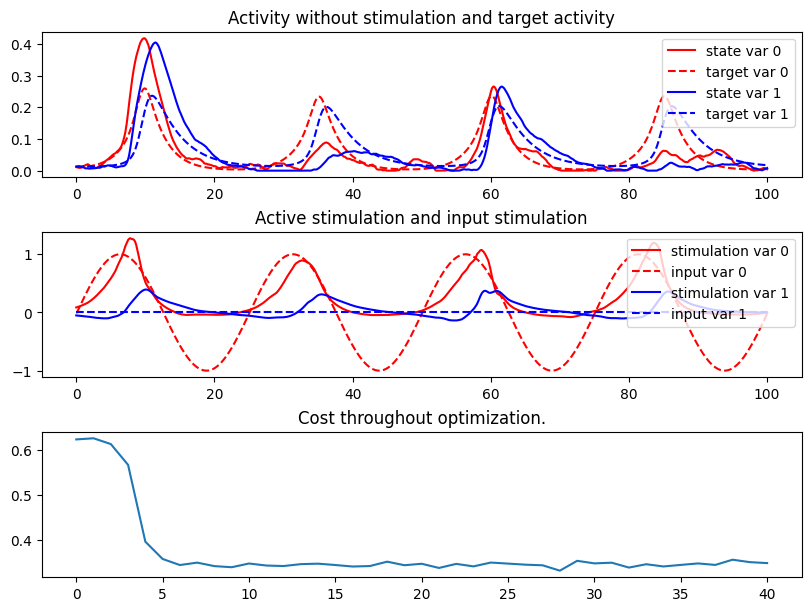

In [5]:
# We set the external stimulation to zero. This is the "initial guess" for the OC algorithm
model.params["exc_ext"] = zero_input
model.params["inh_ext"] = zero_input

# We load the optimal control class
# print array (optional parameter) defines, for which iterations intermediate results will be printed
# Parameters will be taken from the input model
model_controlled = oc_wc.OcWc(model, target, print_array=np.arange(0,101,5),
        M=2, M_validation=500, validate_per_step=True)

# first, we determine a reasonable value of M to perform the optimization with and update the controlled model
M = model_controlled.find_M(sigma)
print("Recommended M for computation of noisy OC: ", M)
model_controlled.M = M

# We run 100 iterations of the optimal control gradient descent algorithm
model_controlled.optimize(40)

state = model_controlled.get_xs()
control = model_controlled.control

plot_oc_singlenode(duration, dt, state, target, control, target_input, model_controlled.cost_history)

### State transitions in single-node
We consider the control task to transition in a bistable state of coesxisitng up state and oscillations in the ALN (mean-dield EIF) model. This task is studied in detail in Reference [1]. Here, we compute the OC for a noisy setup for three different noise strength.

In [3]:
# This function reads out the final state of a simulation
def getfinalstate(model):
    N = model.params.Cmat.shape[0]
    V = len(model.state_vars)
    T = model.getMaxDelay() + 1
    state = np.zeros((N, V, T))
    for v in range(V):
        if "rates" in model.state_vars[v] or "IA" in model.state_vars[v]:
            for n in range(N):
                state[n, v, :] = model.state[model.state_vars[v]][n, -T:]
        else:
            for n in range(N):
                state[n, v, :] = model.state[model.state_vars[v]][n]
    return state

# This function sets the initial state of a model to specific values
def setinitstate(model, state):
    N = model.params.Cmat.shape[0]
    V = len(model.init_vars)
    T = model.getMaxDelay() + 1

    for n in range(N):
        for v in range(V):
            if "rates" in model.init_vars[v] or "IA" in model.init_vars[v]:
                model.params[model.init_vars[v]] = state[:, v, -T:]
            else:
                model.params[model.init_vars[v]] = state[:, v, -1]

    return


# compute the oscillation period of a state trajectory
def getperiod(data, dt):
    maxfreq = []
    for i_d,d in enumerate(data):
        ps = np.abs(np.fft.fft(d))
        ps_ = ps[:int(len(ps)/2)] / (len(ps)/2)
        ps_[0] = 0.
        fr = np.linspace(0,1./(2.*dt),len(ps_))
        maxfreqind = np.where(ps_ == max(ps_[1:]))
        maxfreq.append((1./fr[maxfreqind])[0])

    return np.mean(maxfreq)

[1.9, 1.5]


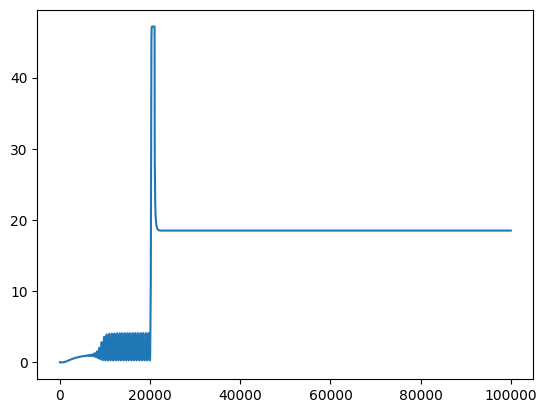

natural period =  58.06322580645162
[1.65627065 1.67784713 1.70058303 1.72331479 1.74603811 1.76874435
 1.79141387 1.81402681 1.83660857 1.85915292]
natural period =  58.06322580645162


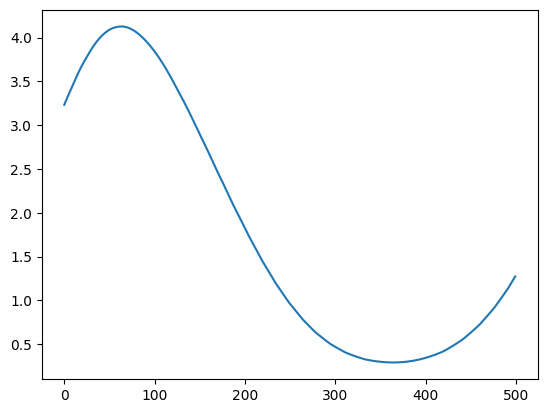

In [5]:
# we set parameters as in the control task discussed in Reference [1] and load the OC computed for the noise-free system
with open(os.path.join(datadir, 'ss_aln.pickle'), 'rb') as f:
    res_read = pickle.load(f)

data = res_read.copy()

N = 1
aln = ALNModel()
dt = aln.params.dt
testd = 1.*1e4
aln.params.duration = testd
aln.params.mue_ext_mean = data["coordinates"][0]
aln.params.mui_ext_mean = data["coordinates"][1]

print(data["coordinates"])

test_input = ZeroInput().generate_input(duration=testd+aln.params.dt, dt=aln.params.dt)
test_input[0,int(2000/dt):int(2100/dt)] = .6
aln.params["ext_exc_current"] = test_input
aln.params["ext_inh_current"] = test_input

aln.run()
plt.plot(aln.rates_exc[0,:])
plt.show()

test_input[0,int(2000/dt):int(2100/dt)] = -0.3

aln.params["ext_exc_current"] = test_input
aln.params["ext_inh_current"] = test_input

aln.run()
plt.plot(aln.rates_exc[0,-500:])

natural_period = getperiod([aln.rates_exc[0,int(1000/dt):]], dt)
print("natural period = ", natural_period)

print(data["init_state"][1][0,0,-10:])

natural_period = getperiod([aln.rates_exc[0,int(1000/dt):]], dt)
print("natural period = ", natural_period)

In [6]:
# hyperparamters of the OC computation
controlmat = np.zeros((1,4))
controlmat[0,0] = 1

costmat = np.zeros((1, 3))
costmat[:,0] = 1.

duration = 1000.
int0 = 1000
int1 = 5000
int2 = 6000

max_cntrl = 5
pr = np.arange(0,101,10)

In [7]:
ci = 0 # up to osc task

aln = ALNModel()
setinitstate(aln, data["init_state"][ci])
aln.params["mue_ext_mean"] =  data["coordinates"][0]
aln.params["mui_ext_mean"] =  data["coordinates"][1]
aln.params.duration = duration

aln.run()

aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
aln_controlled.weights["w_p"] = 0.
aln_controlled.weights["w_2"] = 1.
aln_controlled.weights["w_f_osc"] = data["weights"][ci]

aln_controlled.control = data["control_unshifted"][ci].copy()
aln_controlled.update_input()
aln_controlled.optimize(0)

Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.0002493056410964173
Final cost : -0.0002493056410964173


In [28]:
sigma_array = [7.5 * 1e-3, 15. * 1e-3, 30. * 1e-3]
M_array = [20, 40, 100]

ci = 0

for si, sigma in enumerate(sigma_array):
    aln = ALNModel()
    setinitstate(aln, data["init_state"][ci])
    aln.params["mue_ext_mean"] =  data["coordinates"][0]
    aln.params["mui_ext_mean"] =  data["coordinates"][1]
    aln.params.duration = duration
    aln.params["sigma_ou"] =  sigma

    aln.params["ext_exc_current"] = np.zeros_like(data["control"][ci].copy()[:,0,:])
    aln.run()

    aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat, 
                                  M=2, M_validation=400, validate_per_step=True)


    M_array[si] = aln_controlled.find_M(sigma)
    print("M = ", M_array[si])

M_array = [40, 60, 90]

Optimal control with target oscillation period
M =  39
Optimal control with target oscillation period
M =  60
Optimal control with target oscillation period
M =  87


Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -8.660625554591093
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -8.336424423107086
Compute control for a noisy system
Mean cost in iteration 0: -6.9302815088535485
Minimal cost found at iteration 4
Final cost validated with 100 noise realizations : -8.403102764548025
Compute control for a noisy system
Mean cost in iteration 0: -9.957768645350201
Minimal cost found at iteration 8
Final cost validated with 100 noise realizations : -610.9973845009165
Compute control for a noisy system
Mean cost in iteration 0: 19.684671355516436
Mean cost in iteration 10: 23.385512970038363
Minimal cost found at iteration 8
Final cost validated with 100 noise realizations : 23.142119491888923


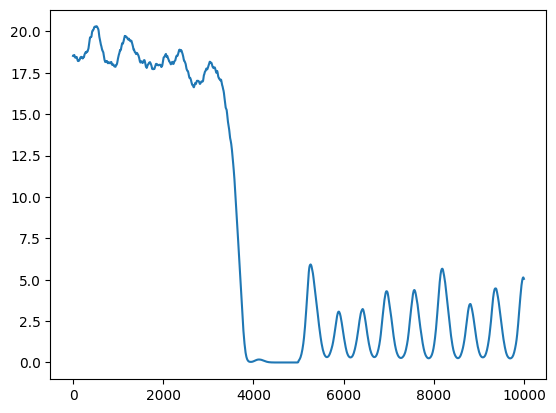

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -625.4570236914429
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -620.1661051533235
Compute control for a noisy system
Mean cost in iteration 0: -608.5633904540383
Minimal cost found at iteration 4
Final cost validated with 100 noise realizations : -649.5786000090052
Compute control for a noisy system
Mean cost in iteration 0: -647.9647559149089
Minimal cost found at iteration 4
Final cost validated with 100 noise realizations : -658.5639358206806
Compute control for a noisy system
Mean cost in iteration 0: -1.5881133843275472
Mean cost in iteration 10: -38.68234845649902
Minimal cost found at iteration 4
Final cost validated with 100 noise realizations : -1.5619540681025428


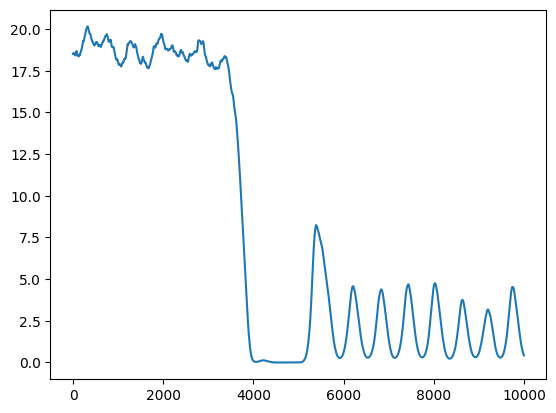

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -656.5480712393246
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -647.4346099120044
Compute control for a noisy system
Mean cost in iteration 0: -645.5760907713588
Minimal cost found at iteration 4
Final cost validated with 100 noise realizations : -640.1407161504951
Compute control for a noisy system
Mean cost in iteration 0: -655.0979420163552
Minimal cost found at iteration 4
Final cost validated with 100 noise realizations : -647.0020834462581
Compute control for a noisy system
Mean cost in iteration 0: 2.4208864174047346
Mean cost in iteration 10: -0.21968333594015746
Minimal cost found at iteration 4
Final cost validated with 100 noise realizations : 2.51258284150825


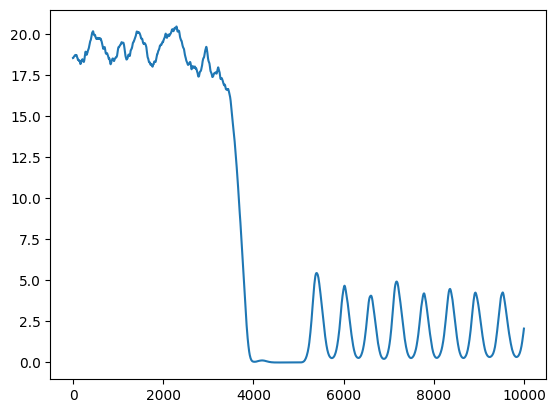

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -26.185803312008964
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -35.52035921890554
Compute control for a noisy system
Mean cost in iteration 0: -28.351216299252883
Minimal cost found at iteration 3
Final cost validated with 100 noise realizations : -440.9430913711198
Compute control for a noisy system
Mean cost in iteration 0: -470.37443277216306
Minimal cost found at iteration 3
Final cost validated with 100 noise realizations : -455.1629397401552
Compute control for a noisy system
Mean cost in iteration 0: -46.322377628237525
Mean cost in iteration 10: -44.46068808331972
Minimal cost found at iteration 3
Final cost validated with 100 noise realizations : -44.42324947506901


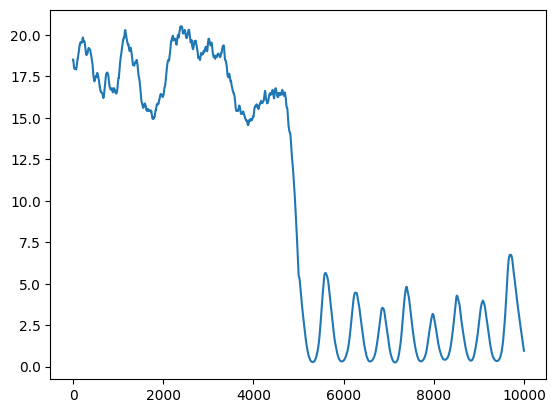

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -432.1670937621349
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -442.0443887789547
Compute control for a noisy system
Mean cost in iteration 0: -455.6990341474487
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -495.4227127799588
Compute control for a noisy system
Mean cost in iteration 0: -457.57319446166315
Minimal cost found at iteration 8
Final cost validated with 100 noise realizations : -414.28099245876217
Compute control for a noisy system
Mean cost in iteration 0: -37.86411233122152
Mean cost in iteration 10: -35.46145720577252
Minimal cost found at iteration 8
Final cost validated with 100 noise realizations : -44.82799297396172


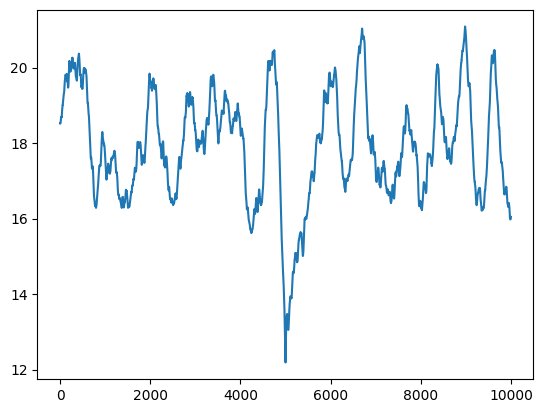

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -422.7678702394741
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -401.13991590473836
Compute control for a noisy system
Mean cost in iteration 0: -402.24085557653166
Minimal cost found at iteration 2
Final cost validated with 100 noise realizations : -470.0763040582037
Compute control for a noisy system
Mean cost in iteration 0: -404.64184948331325
Minimal cost found at iteration 2
Final cost validated with 100 noise realizations : -419.25763079549955
Compute control for a noisy system
Mean cost in iteration 0: -43.24950562506378
Mean cost in iteration 10: -45.784259915879204
Minimal cost found at iteration 2
Final cost validated with 100 noise realizations : -43.05236843639124


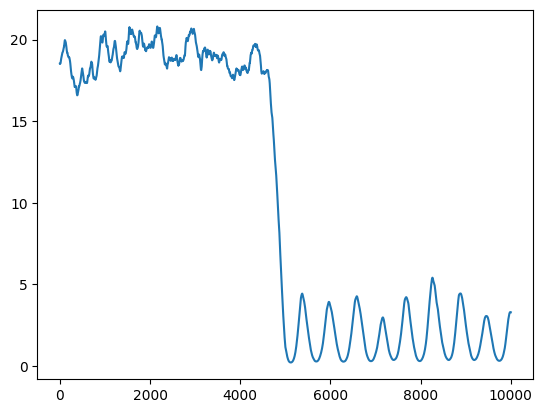

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -194.67961114630089
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -209.34054693680773
Compute control for a noisy system
Mean cost in iteration 0: -193.2905948342571
Minimal cost found at iteration 1
Final cost validated with 100 noise realizations : -173.76797737053778
Compute control for a noisy system
Mean cost in iteration 0: -174.09979675544943
Minimal cost found at iteration 1
Final cost validated with 100 noise realizations : -186.53903392331202
Compute control for a noisy system
Mean cost in iteration 0: -21.359777488672254
Mean cost in iteration 10: -12.854032393766342
Minimal cost found at iteration 1
Final cost validated with 100 noise realizations : -20.804534257005766


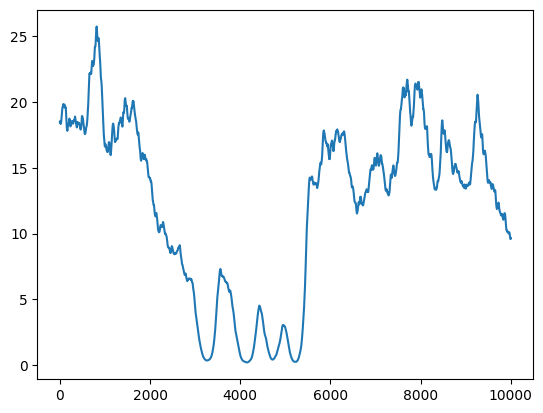

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -193.9623825867855
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -161.39375554041416
Compute control for a noisy system
Mean cost in iteration 0: -186.514289382179
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -261.7032667461253
Compute control for a noisy system
Mean cost in iteration 0: -210.87874670666537
Minimal cost found at iteration 5
Final cost validated with 100 noise realizations : -176.67221938582253
Compute control for a noisy system
Mean cost in iteration 0: -16.12534859999216


KeyboardInterrupt: 

In [ ]:
counter_doc = np.zeros((2, 3))
counter_noinput = np.zeros((2, 3))
counter_noc = np.zeros((2, 3, 3))

control_array = [ [[None, None, None], [None, None, None], [None, None, None]],
                  [[None, None, None], [None, None, None], [None, None, None]] ]

it_av = 1000
M_val = 500
it = 100

for ci in range(2):

    for si, sigma in enumerate(sigma_array):
        aln = ALNModel()
        setinitstate(aln, data["init_state"][ci])
        aln.params["mue_ext_mean"] =  data["coordinates"][0]
        aln.params["mui_ext_mean"] =  data["coordinates"][1]
        aln.params.duration = duration
        aln.params["sigma_ou"] =  sigma

        aln.params["ext_exc_current"] = np.zeros_like(data["control"][ci].copy()[:,0,:])

        for k in range(it_av):
            aln.run()
            if aln.rates_exc[0,-1] < 12:
                counter_noinput[ci, si] += 1

        aln.params["ext_exc_current"] = data["control"][ci].copy()[:,0,:]

        for k in range(it_av):
            aln.run()
            if aln.rates_exc[0,-1] < 12:
                counter_doc[ci, si] += 1

        aln.params["ext_exc_current"] = np.zeros_like(data["control"][ci].copy()[:,0,:])
        aln.run()

        for mi, m in enumerate(M_array):

            aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat, 
                                        M=M_array[si], M_validation=M_val, validate_per_step=True
                                        )
            aln_controlled.weights["w_p"] = 0.
            aln_controlled.weights["w_2"] = 1.
            if ci == 0:
                aln_controlled.weights["w_f_osc"] = 1e3
            elif ci == 1:
                aln_controlled.weights["w_f_osc"] = -1.
            aln_controlled.maximum_control_strength = max_cntrl
            aln_controlled.optimize(0)

            for k in [0,4]:
                aln_controlled.zero_step_encountered = False
                aln_controlled.step = 10**(k)
                aln_controlled.optimize(4)

            if ci == 0:
                control_ = aln_controlled.control.copy()
                aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat, 
                                        M=M_array[si], M_validation=M_val, validate_per_step=True
                                        )
                aln_controlled.weights["w_p"] = 0.
                aln_controlled.weights["w_2"] = 1.
                aln_controlled.weights["w_f_osc"] = 1e2
                aln_controlled.maximum_control_strength = max_cntrl
                aln_controlled.control = control_.copy()
                aln_controlled.update_input()
                aln_controlled.optimize(0)

            aln_controlled.step = 10**(1)
            aln_controlled.optimize(it)

            control_array[ci][si][mi] = aln_controlled.control.copy()

            plt.plot(aln_controlled.get_xs()[0,0,:])
            plt.show()

            aln.params["ext_exc_current"] = aln_controlled.control.copy()[:,0,:]

            for k in range(it_av):
                aln.run()
                if aln.rates_exc[0,-1] < 12:
                    counter_noc[ci, si, mi] += 1

        with open(os.path.join(datadir, 'data_noisy.pickle'), 'wb') as handle:
            pickle.dump([control_array, counter_noinput, counter_doc, counter_noc], handle)

print(counter_noinput)
print(counter_doc)
print(counter_noc)

In [26]:
tex_string = ""

for si, sigma in enumerate(sigma_array):
    tex_string = tex_string + '{:g}'.format(float('{:.3g}'.format(sigma))) + " & "
    for mi, m in enumerate(M_array):
        tex_string = tex_string + str(m) + " ~~~~"
        for ci in range(2):
            tex_string = tex_string + " & " + str(int(np.around(100. * counter_noc[ci, si, mi] / it_av, 0)))  + " & " + str(np.around(0.5 * dt * np.sum(control_array[ci][si][mi][0,0,:]**2), 3))
            tex_string = tex_string + " & " + str(int(np.around(100. * counter_doc[ci, si] / it_av, 0)))  + " & " + str(np.around(0.5 * dt * np.sum(data["control"][ci][:,0,:]**2), 3))
        tex_string = tex_string + "\\\\"
        if mi != 2:
            tex_string = tex_string + " & "

print(tex_string)


0.008 & 4 ~~~~ & 100 & 35.482 & 58 & 0.037 & 13 & 0.159 & 74 & 0.04\\ & 6 ~~~~ & 100 & 67.051 & 58 & 0.037 & 29 & 0.115 & 74 & 0.04\\ & 9 ~~~~ & 99 & 47.787 & 58 & 0.037 & 30 & 0.106 & 74 & 0.04\\0.015 & 4 ~~~~ & 93 & 14.738 & 60 & 0.037 & 94 & 0.0 & 68 & 0.04\\ & 6 ~~~~ & 96 & 14.854 & 60 & 0.037 & 93 & 0.0 & 68 & 0.04\\ & 9 ~~~~ & 95 & 10.073 & 60 & 0.037 & 4 & 0.294 & 68 & 0.04\\0.03 & 4 ~~~~ & 49 & 10.807 & 47 & 0.037 & 45 & 0.0 & 42 & 0.04\\ & 6 ~~~~ & 59 & 44.669 & 47 & 0.037 & 47 & 0.017 & 42 & 0.04\\ & 9 ~~~~ & 54 & 69.848 & 47 & 0.037 & 37 & 0.028 & 42 & 0.04\\


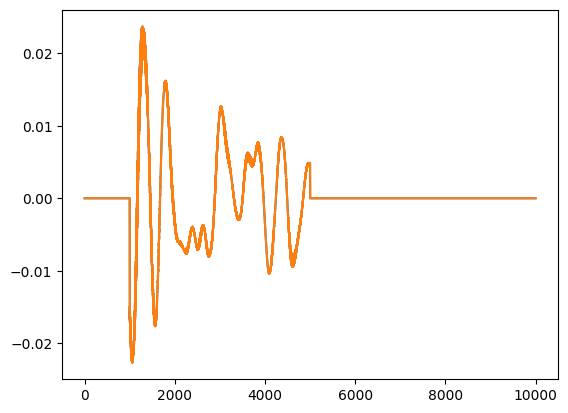

In [23]:
plt.plot(control_array[0][0][0][0,0,:])
plt.plot(control_array[0][1][0][0,0,:])
plt.show()